# Part 2: Training the Digital Brain 🧠
**Supported by the WEL Research Institute (WEL-T) - EDITS Project**

A Digital Twin isn't just a dashboard — it uses Machine Learning to **forecast** the future.

But before we touch any model, let's get the priorities straight. The order that actually
matters in practice is:

1. **Data** — how do we turn a time series into something a model can learn from?
2. **Evaluation** — how do we *honestly* measure if it works?
3. **Model** — only now do we pick an algorithm.

Most people jump straight to step 3. We won't.

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [36]:
# Load the physical simulation we generated in Notebook 1
df_physical = pd.read_csv("synthetic_df_train.csv", index_col=0, parse_dates=True)

print(df_physical.shape)
df_physical.head()

(595, 10)


,temp_air,wind_speed,wind_speed_100m,ghi,dhi,dni,Solar_kW,Wind_kW,Demand_kW,Price_EUR_per_kWh
2026-05-14 00:00:00,6.4,3.888889,7.055556,0.0,0.0,0.0,0.0,0.322222,7.993428,0.139989
2026-05-14 01:00:00,6.4,3.944444,7.138889,0.0,0.0,0.0,0.0,0.355556,6.723471,0.157141
2026-05-14 02:00:00,5.8,3.944444,7.250000,0.0,0.0,0.0,0.0,0.400000,8.295377,0.137484
2026-05-14 03:00:00,5.8,3.750000,6.916667,0.0,0.0,0.0,0.0,0.283333,10.046074,0.153095
2026-05-14 04:00:00,5.4,3.777778,6.944444,0.0,0.0,0.0,0.0,0.288889,6.532927,0.142360



## 1. Data

### 1.0 What are we actually predicting?

Before lags, features, or models: look at the target itself. `Solar_kW` is **zero at night**
and follows a strong daily cycle. This matters a lot:

- A model that just memorizes "it's night → output 0" will look deceptively good on MSE,
  because half the day is trivially easy.
- Any feature engineering we do needs to respect this cycle, or we're hiding the hard part
  of the problem (sunrise/sunset ramps) inside an average.


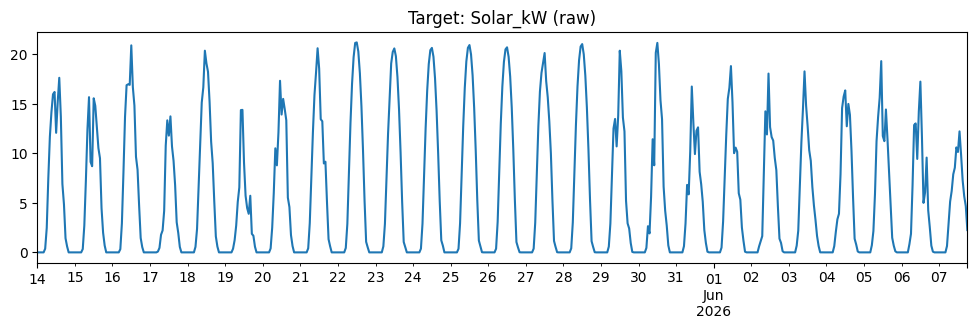

In [37]:
df_physical["Solar_kW"].plot(figsize=(12, 3), title="Target: Solar_kW (raw)")
plt.show()

### 1.1 From time series to tabular data: lags
#
Models like Random Forest don't understand "time" — they understand rows of numbers.
To forecast `Solar_kW` at time *t*, we give the model information available *before* time *t*:
typically its own past values (**lags**) and/or calendar information.
#
**The #1 mistake here is leakage.** Two ways it sneaks in:
#
1. **Wrong shift direction.** `df['Solar_kW'].shift(1)` = value from 1 hour *ago* (correct, this
   is a valid input). `df['Solar_kW'].shift(-1)` = value from 1 hour in the *future* — if that
   ends up as a feature, your model is cheating.
2. **Filling NaNs before splitting.** Shifting creates NaNs at the start of the dataframe.
   If you `fillna()` with a value computed from the *whole* series (e.g. the global mean)
   before doing train/test split, information from the test set leaks backward into training.
#
**Rule of thumb:** create lag features first using only `shift()` (no fill), do the train/test
split, *then* drop or fill remaining NaNs separately in each set.


In [38]:
N_LAGS = 3  # how many past hours to feed the model

df_feat = df_physical.copy()

for lag in range(1, N_LAGS + 1):
    df_feat[f"Solar_kW_lag{lag}"] = df_feat["Solar_kW"].shift(lag)

df_feat[["Solar_kW", "Solar_kW_lag1", "Solar_kW_lag2", "Solar_kW_lag3"]].head(6)

,Solar_kW,Solar_kW_lag1,Solar_kW_lag2,Solar_kW_lag3
2026-05-14 00:00:00,0.000000,NaN,NaN,NaN
2026-05-14 01:00:00,0.000000,0.0,NaN,NaN
2026-05-14 02:00:00,0.000000,0.0,0.0,NaN
2026-05-14 03:00:00,0.000000,0.0,0.0,0.0
2026-05-14 04:00:00,0.000000,0.0,0.0,0.0
2026-05-14 05:00:00,0.368414,0.0,0.0,0.0


### 1.2 Time series feature extraction
#
Beyond raw lags, we can summarize *recent history* with rolling statistics. This gives the
model a sense of "what's the recent trend/volatility" without needing dozens of individual lags.
#
- **Rolling mean** — smoothed recent level (e.g. "average output over the last 3 hours")
- **Rolling std** — recent volatility (useful for wind, less so for solar which is smooth)
- **Rolling min/max** — recent extremes
#
These are the "do it yourself, costs nothing" version of what libraries like `tsfresh` automate
at scale (hundreds of statistical features per series). For a tutorial, a handful of rolling
stats gets you 90% of the value.
#
⚠️ Same leakage rule applies: `rolling(window=3)` by default is fine (it only looks backward),
but `.shift(-1)` after a rolling operation, or `center=True`, would peek into the future.


In [39]:
ROLL_WINDOW = 3

df_feat[f"Solar_kW_roll_mean{ROLL_WINDOW}"] = (
    df_feat["Solar_kW"].rolling(window=ROLL_WINDOW).mean()
)
df_feat[f"Solar_kW_roll_std{ROLL_WINDOW}"] = (
    df_feat["Solar_kW"].rolling(window=ROLL_WINDOW).std()
)

df_feat[["Solar_kW", "Solar_kW_roll_mean3", "Solar_kW_roll_std3"]].head(6)

,Solar_kW,Solar_kW_roll_mean3,Solar_kW_roll_std3
2026-05-14 00:00:00,0.000000,NaN,NaN
2026-05-14 01:00:00,0.000000,NaN,NaN
2026-05-14 02:00:00,0.000000,0.000000,0.000000
2026-05-14 03:00:00,0.000000,0.000000,0.000000
2026-05-14 04:00:00,0.000000,0.000000,0.000000
2026-05-14 05:00:00,0.368414,0.122805,0.212704


### 1.3 Feature engineering: calendar / seasonal signals
#
Solar output has a strong daily cycle (sun rises and sets) and the dataset spans enough days
to have weekly/seasonal structure too. Raw `hour` (0–23) is misleading to a model: hour 23 and
hour 0 are numerically far apart but only 1 hour apart in reality.
#
**Fix: sine/cosine encoding.** Map the hour onto a circle:
#
`Hour_Sin = sin(2π · hour / 24)`, `Hour_Cos = cos(2π · hour / 24)`
#
Two columns are needed because `sin` alone is ambiguous (two different hours can share the
same sine value) — together, (sin, cos) uniquely identify the position on the circle.
#
The same trick applies to day-of-year for seasonal effects.

In [40]:
df_feat["Hour"] = df_feat.index.hour
df_feat["Hour_Sin"] = np.sin(2 * np.pi * df_feat["Hour"] / 24)
df_feat["Hour_Cos"] = np.cos(2 * np.pi * df_feat["Hour"] / 24)

df_feat["DayOfYear"] = df_feat.index.dayofyear
df_feat["Season_Sin"] = np.sin(2 * np.pi * df_feat["DayOfYear"] / 365.25)
df_feat["Season_Cos"] = np.cos(2 * np.pi * df_feat["DayOfYear"] / 365.25)

df_feat[["Hour", "Hour_Sin", "Hour_Cos", "Season_Sin", "Season_Cos"]].head(3)

,Hour,Hour_Sin,Hour_Cos,Season_Sin,Season_Cos
2026-05-14 00:00:00,0,0.000000,1.000000,0.742281,-0.670089
2026-05-14 01:00:00,1,0.258819,0.965926,0.742281,-0.670089
2026-05-14 02:00:00,2,0.500000,0.866025,0.742281,-0.670089


### 1.4 Going multivariate: the dimension explosion problem
#
We have multiple raw signals available: `temp_air`, `wind_speed`, `ghi`, `dhi`, `dni`. If we
naively apply lags + rolling stats to *every* column, feature count explodes:
#
`5 raw columns × (N_LAGS lags + 2 rolling stats) ≈ 25 extra columns` — and that's before
calendar features. More features ≠ better, especially with limited data:
#
- **Curse of dimensionality** — with ~720 hourly samples and 30+ features, the model can
  start fitting noise (more on this in the overfitting section below).
- **Correlated features** — `ghi`, `dni`, `dhi` are physically related; feeding all three
  plus their lags adds redundancy, not information.
#
**Practical strategies to avoid the explosion:**
#
1. **Domain-driven selection** — pick the *physically meaningful* exogenous variable. For
   solar, `ghi` (Global Horizontal Irradiance) is the single strongest driver — it's
   essentially "how much sun is hitting the ground right now."
2. **Lag only the target, engineer features only for exogenous vars** — i.e. don't lag
   everything, just add the *current* value of `ghi`/`temp_air` as a feature (a "physics hint"),
   and reserve lags/rolling stats for the target itself.
3. **Dimensionality reduction (PCA)** — if you do want many raw signals, compress correlated
   groups (e.g. ghi/dni/dhi) into 1-2 principal components instead of feeding all three.
#
For this tutorial we'll go with strategy 2: lag the target, add `ghi` and `temp_air` directly
as physics-informed features.

In [41]:
df_feat["ghi"] = df_physical["ghi"]
df_feat["temp_air"] = df_physical["temp_air"]

FEATURE_COLS = [
    "Hour_Sin", "Hour_Cos", "Season_Sin", "Season_Cos",
    "temp_air", "ghi",
    "Solar_kW_lag1", "Solar_kW_lag2", "Solar_kW_lag3",
    "Solar_kW_roll_mean3", "Solar_kW_roll_std3",
]
TARGET_COL = "Solar_kW"

#Keep a full-index copy (before dropping NaNs) — needed later 
# to predict over the entire dataset for Notebook 3's hand-off.
df_feat_full = df_feat.copy()

#Drop rows with NaNs created by lags/rolling (only at the very start of the series)
df_feat = df_feat.dropna(subset=FEATURE_COLS + [TARGET_COL]).copy()

print(f"Feature count: {len(FEATURE_COLS)}")
print(f"Rows remaining after dropping lag/rolling NaNs: {len(df_feat)}")


Feature count: 11
Rows remaining after dropping lag/rolling NaNs: 592


## 2. Evaluation: Time Series Cross-Validation (TSCV)
#
A normal `train_test_split(shuffle=True)` or `KFold` would let the model train on data from
*after* the point it's predicting — pure leakage, and it will give wildly optimistic results
that fall apart in production.
#
**The fix: `TimeSeriesSplit`** — every fold trains only on the past and validates on the
future. Two extra things worth knowing:
#
- **Expanding vs rolling window** — `TimeSeriesSplit` by default uses an *expanding* training
  window (fold 2's training set includes all of fold 1's). A *rolling* window (fixed-size,
  slides forward) is more realistic if older data becomes irrelevant (e.g. seasonal drift).
- **Gap between train and test** — if you're forecasting 1 hour ahead using a lag-1 feature,
  training right up to the last second before the test fold is fine. But if you forecast
  *24 hours* ahead, you need a `gap` so the test fold doesn't start one timestep after
  training ends — otherwise the "future" you're testing on was basically visible via lags
  at training time.
#
For this tutorial (1-hour-ahead forecast, lag-1 feature), a small/no gap is fine — but it's
the first thing to add if you change the forecast horizon.

In [42]:
from sklearn.model_selection import TimeSeriesSplit

N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)  # add `gap=` here if forecasting further ahead

X = df_feat[FEATURE_COLS]
y = df_feat[TARGET_COL]


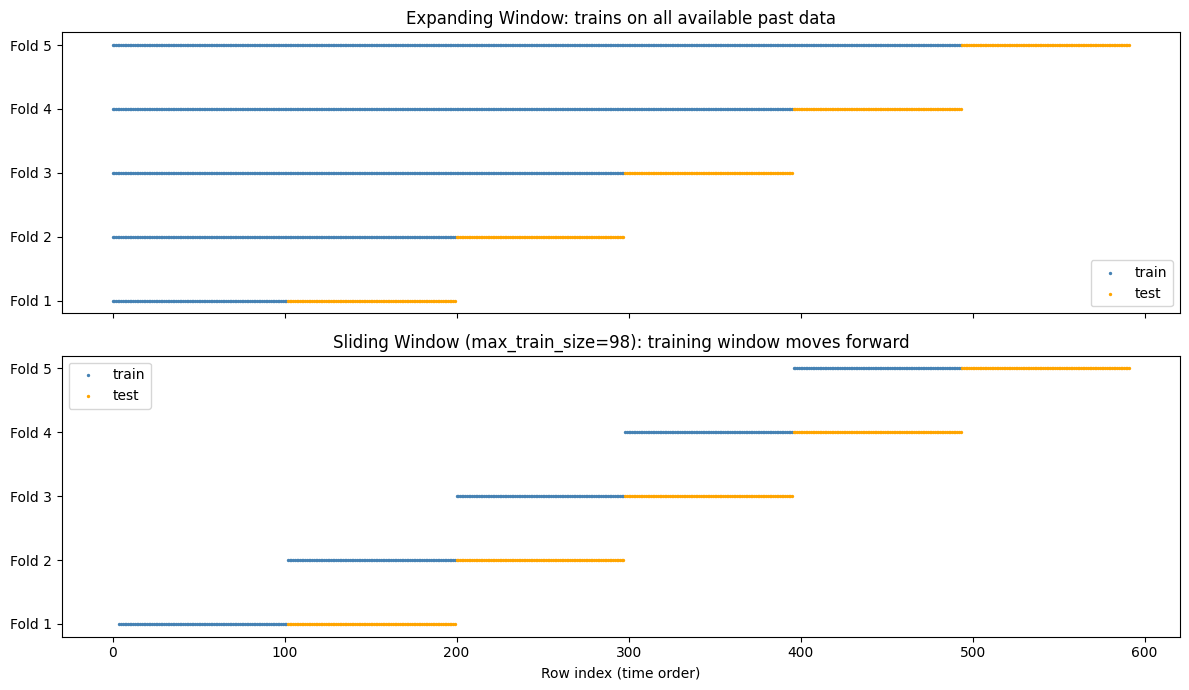

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit

# --- Setup dummy data if not already defined ---
# np.random.seed(42)
# X = np.random.randn(500, 2)
# N_SPLITS = 5

# Define the two cross-validators
# For the sliding window, we set a limit on the training set size
max_train_size = len(X) // (N_SPLITS + 1)  # Adjust this size as needed

tscv_expanding = TimeSeriesSplit(n_splits=N_SPLITS)
tscv_sliding = TimeSeriesSplit(n_splits=N_SPLITS, max_train_size=max_train_size)

# Create a figure with 2 subplots, sharing the same x-axis for easier comparison
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 7), sharex=True)

# 1. Plot Expanding Window (Your original approach)
for i, (train_idx, test_idx) in enumerate(tscv_expanding.split(X)):
    ax1.scatter(train_idx, [i] * len(train_idx), c="steelblue", s=2, label="train" if i == 0 else None)
    ax1.scatter(test_idx, [i] * len(test_idx), c="orange", s=2, label="test" if i == 0 else None)
ax1.set_yticks(range(N_SPLITS))
ax1.set_yticklabels([f"Fold {i+1}" for i in range(N_SPLITS)])
ax1.set_title("Expanding Window: trains on all available past data")
ax1.legend()

# 2. Plot Sliding Window
for i, (train_idx, test_idx) in enumerate(tscv_sliding.split(X)):
    ax2.scatter(train_idx, [i] * len(train_idx), c="steelblue", s=2, label="train" if i == 0 else None)
    ax2.scatter(test_idx, [i] * len(test_idx), c="orange", s=2, label="test" if i == 0 else None)
ax2.set_yticks(range(N_SPLITS))
ax2.set_yticklabels([f"Fold {i+1}" for i in range(N_SPLITS)])
ax2.set_xlabel("Row index (time order)")
ax2.set_title(f"Sliding Window (max_train_size={max_train_size}): training window moves forward")
ax2.legend()

plt.tight_layout()
plt.show()

### 2.1 The baseline you must beat: naive forecasts

Before any ML model, ask: *what's the dumbest possible forecast, and how good is it?*

- **Persistence**: "next hour = this hour" → `y_pred[t] = y[t-1]`
- **Seasonal naive**: "this hour = same hour yesterday" → `y_pred[t] = y[t-24]`

For solar, seasonal naive is usually shockingly good — yesterday at noon is a decent guess for
today at noon. If your fancy model can't beat this, it hasn't learned anything useful.


In [44]:
from sklearn.metrics import mean_squared_error

#Persistence baseline (already have this as Solar_kW_lag1)
mse_persistence = mean_squared_error(df_feat[TARGET_COL], df_feat["Solar_kW_lag1"])

#Seasonal naive baseline (same hour, 24h ago)
seasonal_naive = df_physical["Solar_kW"].shift(24).reindex(df_feat.index)
mask = seasonal_naive.notna()
mse_seasonal_naive = mean_squared_error(df_feat[TARGET_COL][mask], seasonal_naive[mask])

print(f"Persistence baseline MSE:    {mse_persistence:.2f}")
print(f"Seasonal naive baseline MSE: {mse_seasonal_naive:.2f}")


Persistence baseline MSE:    6.63
Seasonal naive baseline MSE: 7.68


## 3. Model: simple first, then deep
### 3.1 Simple model: Random Forest
#
Now we train a Random Forest. Use `TREE_DEPTH` to explore underfitting vs overfitting:
#
- `TREE_DEPTH = 1` → underfitting (model too simple)
- `TREE_DEPTH = 5` → roughly right
- `TREE_DEPTH = 50` → overfitting (train error ≈ 0, test error large)
#
We evaluate using the **last fold** of TSCV (most recent data = most realistic test).

In [45]:
from sklearn.ensemble import RandomForestRegressor

# ==========================================
# 🛠️ YOUR TURN: Tweak this parameter!
# Try 1, 5, and 50
TREE_DEPTH = 5
# ==========================================

# Use the final TSCV split as our train/test set
train_idx, test_idx = list(tscv.split(X))[-1]
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

model_solar = RandomForestRegressor(max_depth=TREE_DEPTH, n_estimators=20, random_state=42)
model_solar.fit(X_train, y_train)

y_pred_train = model_solar.predict(X_train)
y_pred_test = model_solar.predict(X_test)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

print(f"🌲 Tree Depth: {TREE_DEPTH}")
print(f"📊 Training MSE: {mse_train:.2f}")
print(f"🔮 Test MSE:     {mse_test:.2f}")
print(f"--- baselines for comparison ---")
print(f"Persistence MSE:    {mse_persistence:.2f}")
print(f"Seasonal naive MSE: {mse_seasonal_naive:.2f}")

🌲 Tree Depth: 5
📊 Training MSE: 0.10
🔮 Test MSE:     0.12
--- baselines for comparison ---
Persistence MSE:    6.63
Seasonal naive MSE: 7.68


In [46]:
# Calculate the variance of the test set
variance_test = y_test.var(ddof=0)

# Calculate the NMSE for our baselines and our Random Forest model (assuming TREE_DEPTH=5)
# Note: These values are calculated using the test set's offline variance
nmse_persistence = mse_persistence / variance_test
nmse_seasonal_naive = mse_seasonal_naive / variance_test

# We will fit the model here to ensure variables are defined if cells are run out of order
nmse_ours = mse_test / variance_test

print("\n--- Offline NMSE Comparison (Lower is Better) ---")
print(f"Persistence NMSE:      {nmse_persistence:.3f}")
print(f"Seasonal Naive NMSE:   {nmse_seasonal_naive:.3f}")
print(f"Random Forest NMSE:    {nmse_ours:.3f} (R² equivalent: {1 - nmse_ours:.3f})")


--- Offline NMSE Comparison (Lower is Better) ---
Persistence NMSE:      0.216
Seasonal Naive NMSE:   0.250
Random Forest NMSE:    0.004 (R² equivalent: 0.996)


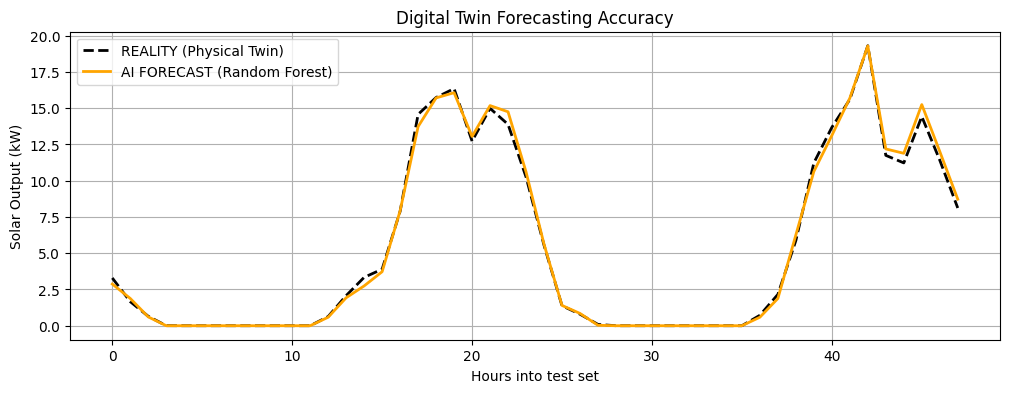

In [47]:
plt.figure(figsize=(12, 4))
plt.plot(y_test.values[:48], label="REALITY (Physical Twin)", color="black", linewidth=2, linestyle="--")
plt.plot(y_pred_test[:48], label="AI FORECAST (Random Forest)", color="orange", linewidth=2)
plt.title("Digital Twin Forecasting Accuracy")
plt.xlabel("Hours into test set")
plt.ylabel("Solar Output (kW)")
plt.legend()
plt.grid(True)
plt.show()

### 3.2 Feature importance — what is the model actually using?
#
A nice side benefit of "simple first": Random Forest gives us feature importances for free.
This tells us *which* features the model relies on — and is a good sanity check (does `ghi`
dominate, as physics would suggest?).

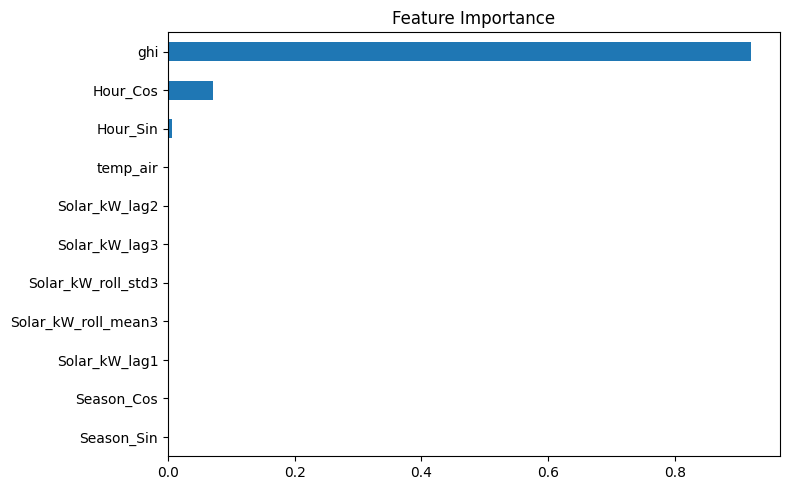

In [48]:
importances = pd.Series(model_solar.feature_importances_, index=FEATURE_COLS).sort_values()
importances.plot(kind="barh", figsize=(8, 5), title="Feature Importance")
plt.tight_layout()
plt.show()

### 3.3 Error analysis: where does the model fail?

A single MSE number hides *when* errors happen. Solar forecasting is trivially easy at night
(output is always ~0) and hardest around sunrise/sunset ramps. Breaking down error by hour of
day reveals this.

In [49]:
X_test.columns

Index(['Hour_Sin', 'Hour_Cos', 'Season_Sin', 'Season_Cos', 'temp_air', 'ghi',
       'Solar_kW_lag1', 'Solar_kW_lag2', 'Solar_kW_lag3',
       'Solar_kW_roll_mean3', 'Solar_kW_roll_std3'],
      dtype='object')

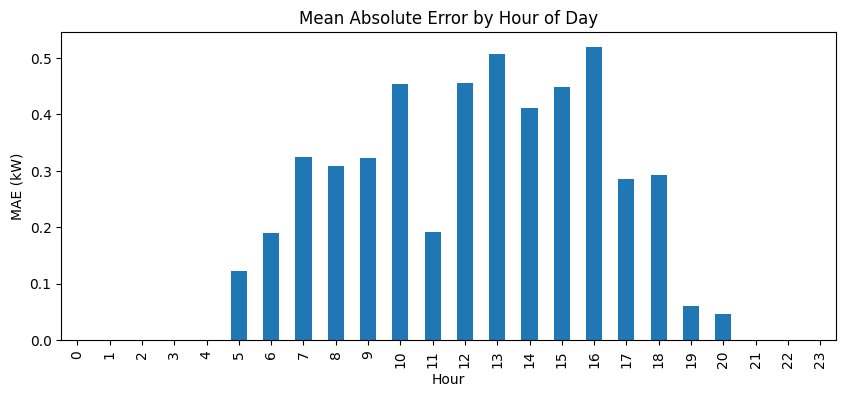

In [50]:
error_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": y_pred_test,
    "Hour": df_feat.loc[X_test.index, "Hour"].values,
})
error_df["abs_error"] = (error_df["y_true"] - error_df["y_pred"]).abs()

error_by_hour = error_df.groupby("Hour")["abs_error"].mean()
error_by_hour.plot(kind="bar", figsize=(10, 4), title="Mean Absolute Error by Hour of Day")
plt.ylabel("MAE (kW)")
plt.show()

## Hand-off to Notebook 3
#
For the optimization notebook, we need the model's predictions across the *entire* dataset
(not just the test fold) so the battery optimizer can act on forecasts rather than ground truth.


In [51]:
import joblib
joblib.dump(model_solar, f"rf_Solar_kW_model.joblib")

['rf_Solar_kW_model.joblib']